# Public Transport Delay Prediction using Machine Learning

## Time Series Analysis and Forecasting

### Objective

Analyse how **actual arrival delay** changes over time and build a leakage-free time-series forecasting workflow.

**Primary target:** daily mean `actual_arrival_delay_min`

### Questions addressed

1. How does average arrival delay change across the observed dates?
2. Are there visible weekday patterns?
3. Does the recorded `season` field provide meaningful seasonal information?
4. Can simple forecasting models predict the next few days better than a naive baseline?

### Important dataset limitation

The dataset covers only **January 2023 for approximately three weeks**, so this notebook treats seasonality as exploratory rather than claiming annual or long-term seasonal behaviour.


## Workflow

1. Load and validate the raw dataset
2. Create a daily time series
3. Check date coverage and incomplete days
4. Explore daily, weekday, and recorded-season patterns
5. Examine weekly seasonality with decomposition
6. Create chronological train/validation/test splits
7. Compare simple forecasting models
8. Select the model using validation RMSE
9. Refit the selected model and evaluate on the untouched test period
10. Inspect forecast errors
11. Produce a short future forecast
12. Save the selected forecasting artifact and results


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

RANDOM_STATE = 42

print("Libraries imported successfully.")


Libraries imported successfully.


## Load the Raw Dataset

Notebook 5 intentionally starts from the raw dataset rather than the random train/test splits from Notebook 2.

Time-series data must preserve **chronological order**, so the split strategy used here is different from the random splits used for classification and regression.


In [3]:
# Load the raw dataset 

df = pd.read_csv("../data/public_transport_delays.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 24)


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


## Validate the Time and Target Columns

The time-series target is the realised arrival delay in minutes.

The target is aggregated by date rather than forecasting individual trips because the project currently contains a short observation window and the trip-level records are not a uniformly sampled time series.


In [4]:
required_columns = [
    "date",
    "actual_arrival_delay_min",
    "delayed",
    "trip_id",
    "season"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError("Missing required columns: " + ", ".join(missing_columns))

df["date"] = pd.to_datetime(df["date"], errors="coerce")

if df["date"].isna().any():
    raise ValueError("Some date values could not be parsed.")

df = df.sort_values(["date", "trip_id"]).reset_index(drop=True)

print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Number of rows:", len(df))
print("Number of unique dates:", df["date"].nunique())


Date range: 2023-01-01 to 2023-01-22
Number of rows: 2000
Number of unique dates: 22


## Build the Daily Time Series

The main forecasting target is the **daily mean arrival delay**.

Additional daily measures are retained for interpretation:
- median arrival delay
- delayed-trip rate
- number of trips observed

Keeping trip counts is important because the final date in this dataset is incomplete.


In [5]:
daily = (
    df.groupby("date")
      .agg(
          mean_arrival_delay_min=("actual_arrival_delay_min", "mean"),
          median_arrival_delay_min=("actual_arrival_delay_min", "median"),
          delayed_rate=("delayed", "mean"),
          trips=("trip_id", "count")
      )
      .sort_index()
)

daily


,mean_arrival_delay_min,median_arrival_delay_min,delayed_rate,trips
date,,,,
2023-01-01,12.013158,11.0,0.710526,76
2023-01-02,15.000000,14.0,0.864583,96
2023-01-03,13.812500,15.0,0.760417,96
2023-01-04,13.916667,13.5,0.791667,96
2023-01-05,12.031250,12.5,0.666667,96
2023-01-06,14.489583,15.0,0.802083,96
2023-01-07,13.375000,14.0,0.750000,96
2023-01-08,13.750000,14.0,0.760417,96
2023-01-09,13.718750,13.5,0.708333,96


## Check Observation Completeness

The dataset does not contain the same number of trips on every date. A partially observed day can distort a daily mean and should not automatically be treated as a normal full day.

The typical number of trips per day is estimated from the median daily count. Days with substantially fewer observations are excluded from the forecasting series, but the exclusion is documented rather than silently dropped.

In [6]:
typical_daily_trips = daily["trips"].median()
completeness_threshold = 0.95 * typical_daily_trips

complete_daily = daily.loc[
    daily["trips"] >= completeness_threshold
].copy()

excluded_days = daily.loc[
    daily["trips"] < completeness_threshold
].copy()

print("Typical daily trip count:", int(typical_daily_trips))
print("Completeness threshold:", round(completeness_threshold, 1))
print("Complete days:", len(complete_daily))
print("Excluded days:", len(excluded_days))

if len(excluded_days) > 0:
    print("\nExcluded dates:")
    display(excluded_days.reset_index())

print("\nForecasting date range:")
print(complete_daily.index.min().date(), "to", complete_daily.index.max().date())

Typical daily trip count: 96
Completeness threshold: 91.2
Complete days: 20
Excluded days: 2

Excluded dates:


,date,mean_arrival_delay_min,median_arrival_delay_min,delayed_rate,trips
0,2023-01-01,12.013158,11.0,0.710526,76
1,2023-01-22,19.500000,22.0,1.000000,4



Forecasting date range:
2023-01-02 to 2023-01-21


## Daily Delay Pattern

This plot shows the observed daily mean arrival delay.

Because the observation period is short, the purpose is to identify short-term variation rather than infer long-term trends.


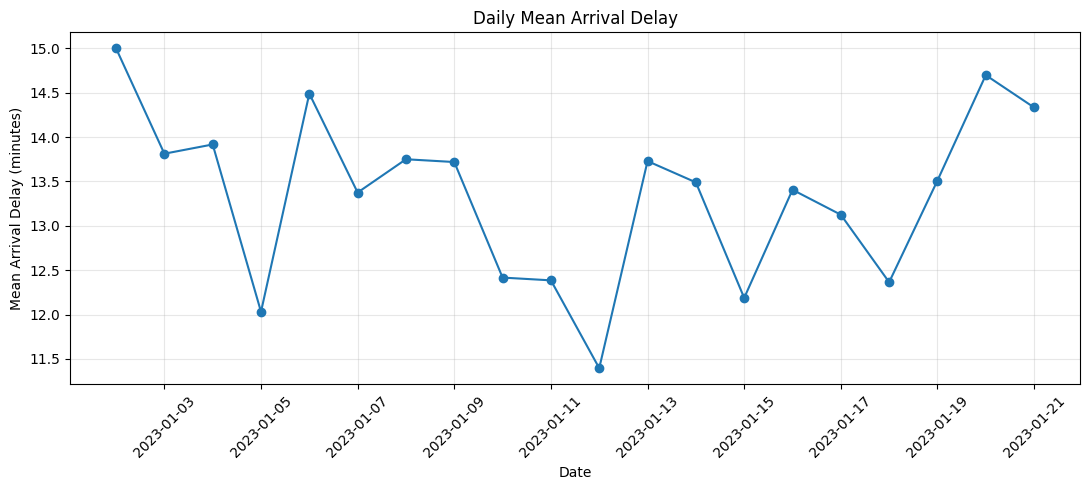

In [7]:
plt.figure(figsize=(11, 5))
plt.plot(
    complete_daily.index,
    complete_daily["mean_arrival_delay_min"],
    marker="o"
)
plt.xlabel("Date")
plt.ylabel("Mean Arrival Delay (minutes)")
plt.title("Daily Mean Arrival Delay")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Daily Delay Distribution and Delayed-Trip Rate

The mean delay and the percentage of trips classified as delayed measure different aspects of service performance.

The delayed rate uses the existing dataset definition of `delayed`; no new target definition is introduced here.


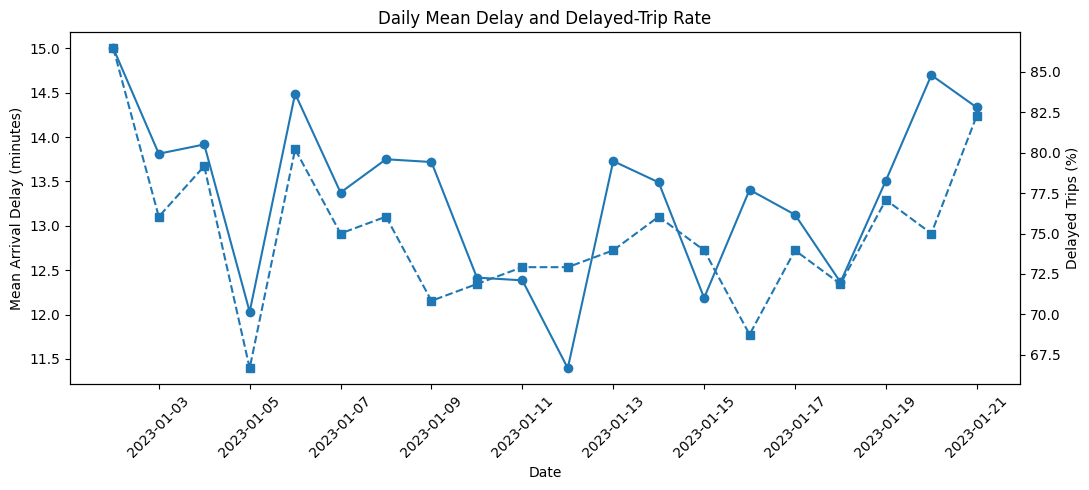

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    complete_daily.index,
    complete_daily["mean_arrival_delay_min"],
    marker="o",
    label="Mean delay (min)"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Mean Arrival Delay (minutes)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    complete_daily.index,
    complete_daily["delayed_rate"] * 100,
    marker="s",
    linestyle="--",
    label="Delayed rate"
)
ax2.set_ylabel("Delayed Trips (%)")

plt.title("Daily Mean Delay and Delayed-Trip Rate")
fig.tight_layout()
plt.show()


## Weekday Pattern

Weekday is derived directly from the calendar date rather than relying on the dataset's `weekday` column.

This provides a calendar-based view of whether delays differ between Monday, Tuesday, and other days of the week.


In [9]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["calendar_weekday"] = df["date"].dt.day_name()

weekday_summary = (
    df.groupby("calendar_weekday")
      .agg(
          mean_delay=("actual_arrival_delay_min", "mean"),
          delayed_rate=("delayed", "mean"),
          trips=("trip_id", "count")
      )
      .reindex(weekday_order)
)

weekday_summary


,mean_delay,delayed_rate,trips
calendar_weekday,,,
Monday,14.041667,0.753472,288
Tuesday,13.118056,0.739583,288
Wednesday,12.888889,0.746528,288
Thursday,12.312500,0.722222,288
Friday,14.305556,0.763889,288
Saturday,13.732639,0.777778,288
Sunday,12.797794,0.742647,272


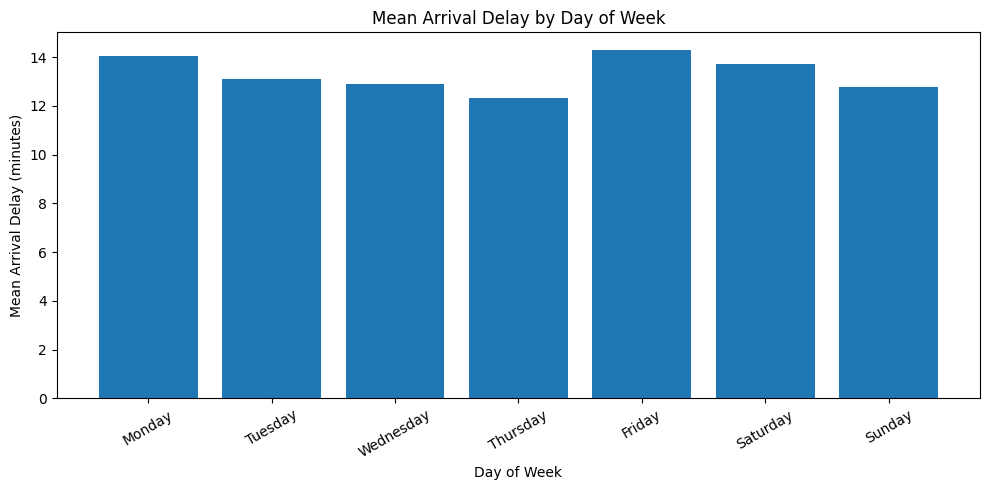

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(
    weekday_summary.index,
    weekday_summary["mean_delay"]
)
plt.xlabel("Day of Week")
plt.ylabel("Mean Arrival Delay (minutes)")
plt.title("Mean Arrival Delay by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Recorded Season Field

The source dataset contains a `season` column, but the observed dates cover only January 2023 while the field contains multiple season labels.

Therefore, this section is descriptive only. It should **not** be interpreted as evidence of real annual seasonal variation in this dataset.


In [11]:
season_summary = (
    df.groupby("season")
      .agg(
          mean_delay=("actual_arrival_delay_min", "mean"),
          delayed_rate=("delayed", "mean"),
          trips=("trip_id", "count")
      )
      .sort_values("mean_delay", ascending=False)
)

season_summary


,mean_delay,delayed_rate,trips
season,,,
Autumn,13.887500,0.756250,480
Spring,13.404382,0.749004,502
Winter,13.307692,0.763158,494
Summer,12.723282,0.730916,524


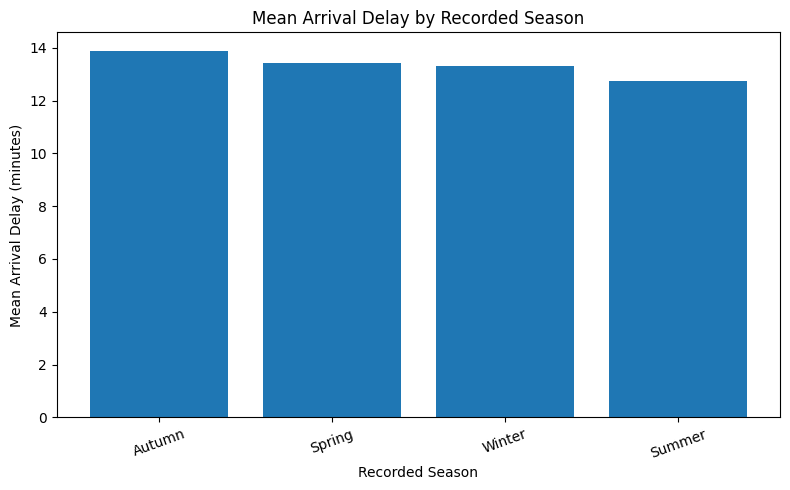

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(
    season_summary.index,
    season_summary["mean_delay"]
)
plt.xlabel("Recorded Season")
plt.ylabel("Mean Arrival Delay (minutes)")
plt.title("Mean Arrival Delay by Recorded Season")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Weekly Seasonality: Exploratory Decomposition

A 7-day period is used to inspect possible weekly structure.

With only a few weeks of observations, any seasonal component should be treated as exploratory and not as a reliable estimate of long-term weekly behaviour.


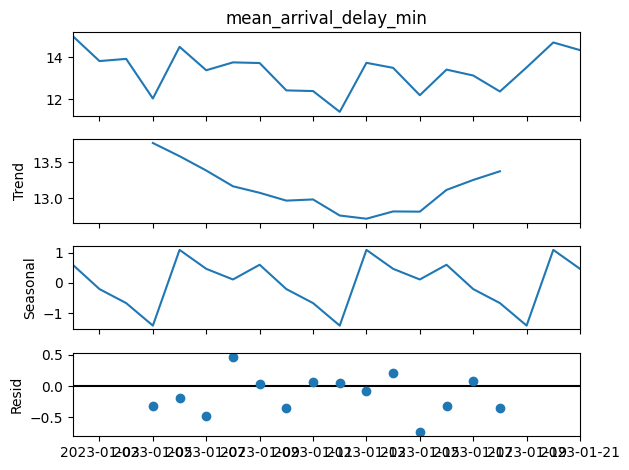

In [21]:
daily_series = complete_daily["mean_arrival_delay_min"].asfreq("D")

if daily_series.isna().any():
    raise ValueError(
        "The complete-day series contains missing calendar dates. "
        "Inspect the date coverage before applying decomposition."
    )

if len(daily_series) < 2 * 7:
    print("Not enough daily observations for a stable 7-day decomposition.")
else:
    decomposition = seasonal_decompose(
        daily_series,
        model="additive",
        period=7
    )
    decomposition.plot()
    plt.tight_layout()
    plt.show()


## Chronological Train / Validation / Test Split

The final chronological observations are reserved for testing.

- **Training:** earliest observations
- **Validation:** next observations, used for model selection
- **Test:** final observations, kept untouched until final evaluation

This prevents future observations from being used to train or select the model.


In [22]:
TEST_SIZE = 4
VALIDATION_SIZE = 3

if len(daily_series) <= TEST_SIZE + VALIDATION_SIZE + 5:
    raise ValueError(
        "Too few observations for the planned chronological split."
    )

test_series = daily_series.iloc[-TEST_SIZE:]
train_val_series = daily_series.iloc[:-TEST_SIZE]

validation_series = train_val_series.iloc[-VALIDATION_SIZE:]
train_series = train_val_series.iloc[:-VALIDATION_SIZE]

print("Training observations:", len(train_series))
print("Validation observations:", len(validation_series))
print("Test observations:", len(test_series))

print("\nTraining:", train_series.index.min().date(), "to", train_series.index.max().date())
print("Validation:", validation_series.index.min().date(), "to", validation_series.index.max().date())
print("Test:", test_series.index.min().date(), "to", test_series.index.max().date())


Training observations: 13
Validation observations: 3
Test observations: 4

Training: 2023-01-02 to 2023-01-14
Validation: 2023-01-15 to 2023-01-17
Test: 2023-01-18 to 2023-01-21


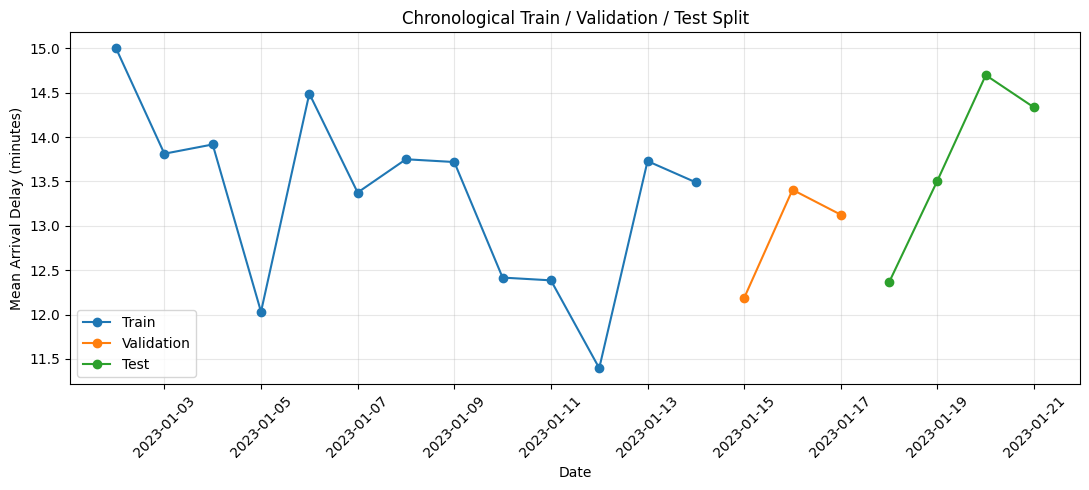

In [23]:
plt.figure(figsize=(11, 5))
plt.plot(train_series.index, train_series.values, marker="o", label="Train")
plt.plot(validation_series.index, validation_series.values, marker="o", label="Validation")
plt.plot(test_series.index, test_series.values, marker="o", label="Test")
plt.xlabel("Date")
plt.ylabel("Mean Arrival Delay (minutes)")
plt.title("Chronological Train / Validation / Test Split")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Forecasting Models

Four compact models are evaluated:

1. **Naive forecast** — repeats the last observed value.
2. **3-day moving average** — recursively forecasts using the latest three values.
3. **Simple Exponential Smoothing** — gives greater weight to recent observations.
4. **ARIMA(1,0,0)** — models short-term autoregressive structure.

The validation RMSE is used for model selection.


In [24]:
def naive_forecast(history, horizon):
    return np.repeat(history.iloc[-1], horizon)


def moving_average_forecast(history, horizon, window=3):
    values = list(history.astype(float).values)

    for _ in range(horizon):
        prediction = float(np.mean(values[-window:]))
        values.append(prediction)

    return np.array(values[-horizon:])


def simple_exponential_smoothing_forecast(history, horizon):
    model = SimpleExpSmoothing(
        history,
        initialization_method="estimated"
    ).fit(optimized=True)
    return np.asarray(model.forecast(horizon), dtype=float)


def arima_forecast(history, horizon):
    model = ARIMA(
        history,
        order=(1, 0, 0),
        trend="c"
    ).fit()
    return np.asarray(model.forecast(horizon), dtype=float)


def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted))
    }


In [25]:
forecast_functions = {
    "Naive Last Value": naive_forecast,
    "3-Day Moving Average": moving_average_forecast,
    "Simple Exponential Smoothing": simple_exponential_smoothing_forecast,
    "ARIMA(1,0,0)": arima_forecast,
}

validation_results = []

for model_name, forecast_function in forecast_functions.items():
    predictions = forecast_function(train_series, len(validation_series))
    metrics = regression_metrics(validation_series.values, predictions)

    validation_results.append({
        "Model": model_name,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"]
    })

validation_results = (
    pd.DataFrame(validation_results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

validation_results.round(4)


,Model,MAE,RMSE
0,3-Day Moving Average,0.2811,0.4014
1,Simple Exponential Smoothing,0.4802,0.6824
2,"ARIMA(1,0,0)",0.4864,0.6941
3,Naive Last Value,0.5833,0.7822


## Validation Results

The forecasting models were compared using MAE and RMSE on the validation period.

The **3-Day Moving Average** achieved the lowest validation error, with a **MAE of 0.2811 minutes** and an **RMSE of 0.4014 minutes**. Simple Exponential Smoothing, ARIMA(1,0,0), and the Naive Last Value method produced higher errors.

The results indicate that, for this short observation period, the recent three-day average provides the closest forecasts to the observed daily mean arrival delays.

The **3-Day Moving Average** is therefore selected for final evaluation on the untouched test period.

## Validation Model Selection

The model with the **lowest validation RMSE** is selected.

This choice is made before looking at the final test period, keeping the test observations available for an unbiased final evaluation.


In [26]:
best_model_name = validation_results.iloc[0]["Model"]

print("Selected model:", best_model_name)
print("Validation RMSE:", round(validation_results.iloc[0]["RMSE"], 4))


Selected model: 3-Day Moving Average
Validation RMSE: 0.4014


## Final Test Forecast

The selected model is now refit using the combined **training + validation** period.

The final test period remains untouched until this point.


In [27]:
selected_forecast_function = forecast_functions[best_model_name]

final_train_series = train_val_series.copy()
test_predictions = selected_forecast_function(
    final_train_series,
    len(test_series)
)

test_metrics = regression_metrics(
    test_series.values,
    test_predictions
)

final_test_results = pd.DataFrame([{
    "Model": best_model_name,
    "MAE": test_metrics["MAE"],
    "RMSE": test_metrics["RMSE"]
}])

final_test_results.round(4)


,Model,MAE,RMSE
0,3-Day Moving Average,0.9604,1.0946


## Final Test Evaluation

The selected **3-Day Moving Average** model was evaluated on the previously untouched test period.

The model achieved:

- **MAE:** 0.9604 minutes
- **RMSE:** 1.0946 minutes

The MAE indicates that the daily mean arrival-delay forecasts were, on average, approximately **0.96 minutes** away from the actual values.

The test RMSE of **1.0946 minutes** is higher than the validation RMSE of **0.4014 minutes**, indicating that the model performed less accurately on the unseen test period.

Despite this difference, the forecasting approach provides a useful short-term baseline for modelling daily arrival-delay behaviour. The results should be interpreted within the limitation of the relatively short observation period in the dataset.

## Final Test Interpretation

Use the final test metrics to assess how well the selected forecasting method generalises to the latest observed period.

The main metric is RMSE, while MAE provides an easier interpretation in minutes.

Because the dataset contains only a short period of daily observations, the test result should be treated as evidence for this dataset rather than as a broad claim about public transport systems in general.


In [28]:
test_forecast_df = pd.DataFrame({
    "actual": test_series.values,
    "predicted": test_predictions,
}, index=test_series.index)

test_forecast_df["residual"] = (
    test_forecast_df["actual"] - test_forecast_df["predicted"]
)

display(test_forecast_df.round(4))


,actual,predicted,residual
date,,,
2023-01-18,12.3646,12.9062,-0.5417
2023-01-19,13.5104,13.1458,0.3646
2023-01-20,14.6979,13.0590,1.6389
2023-01-21,14.3333,13.0370,1.2963


## Test Forecast Error Analysis

The table shows the actual daily mean arrival delays, the forecasts produced by the 3-Day Moving Average model, and the resulting residuals.

The model produced relatively small errors for some dates. For example, on **18 January**, the actual delay was **12.3646 minutes** and the forecast was **12.9062 minutes**, giving a residual of **-0.5417 minutes**.

The largest error among the displayed observations occurred on **20 January**, where the actual delay was **14.6979 minutes** compared with a forecast of **13.0590 minutes**, resulting in a residual of **1.6389 minutes**.

Both positive and negative residuals are present, showing that the model makes both overpredictions and underpredictions. The test-set results therefore indicate that the model captures the general level of daily delay but does not perfectly reproduce day-to-day variation.

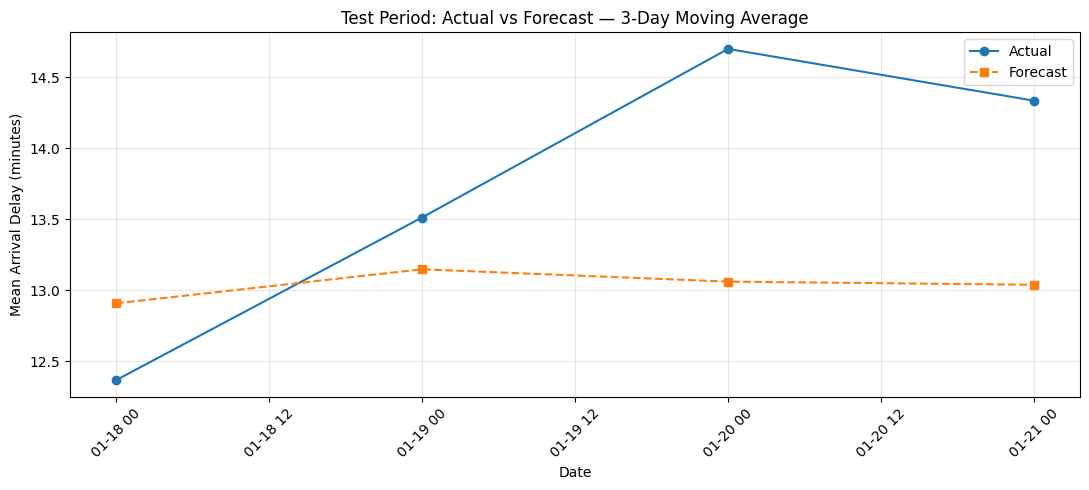

In [29]:
plt.figure(figsize=(11, 5))
plt.plot(
    test_forecast_df.index,
    test_forecast_df["actual"],
    marker="o",
    label="Actual"
)
plt.plot(
    test_forecast_df.index,
    test_forecast_df["predicted"],
    marker="s",
    linestyle="--",
    label="Forecast"
)
plt.xlabel("Date")
plt.ylabel("Mean Arrival Delay (minutes)")
plt.title(f"Test Period: Actual vs Forecast — {best_model_name}")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Actual vs Forecast Analysis

The test-period plot compares the observed daily mean arrival delay with the forecasts generated by the 3-Day Moving Average model.

The forecasts remain relatively close to the recent average, while the actual values show greater day-to-day variation. The model captures the general level of arrival delay but responds more slowly when the actual delay changes substantially.

For example, on **20 January**, the actual mean delay increased to approximately **14.70 minutes**, while the forecast was approximately **13.06 minutes**. This illustrates the smoothing effect of the moving-average approach.

Overall, the plot is consistent with the test RMSE of **1.0946 minutes**, showing that the model provides reasonable short-term estimates but does not fully capture sudden changes in daily delay.

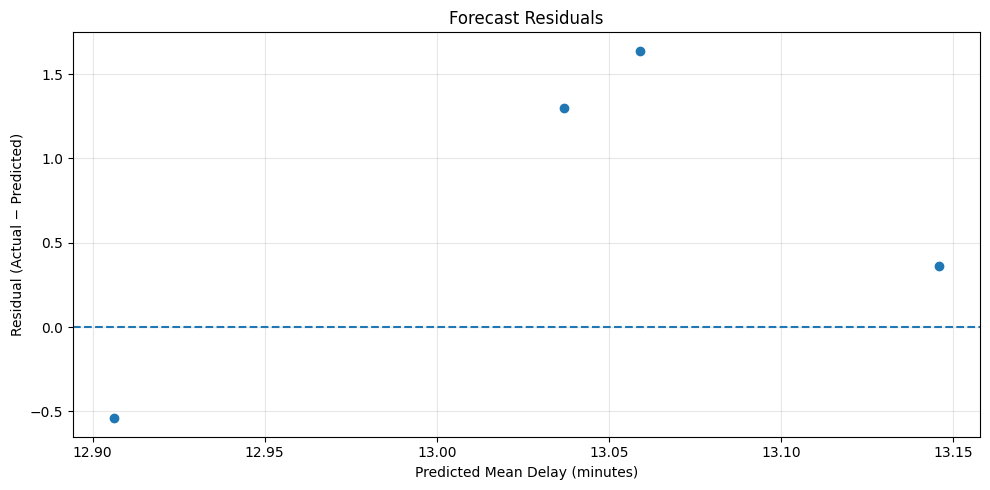

In [30]:
plt.figure(figsize=(10, 5))
plt.axhline(0, linestyle="--")
plt.scatter(
    test_forecast_df["predicted"],
    test_forecast_df["residual"]
)
plt.xlabel("Predicted Mean Delay (minutes)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Forecast Residuals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Forecast Residual Analysis

The residuals are calculated as:

**Residual = Actual − Predicted**

The residual plot shows errors on both sides of the zero line, indicating that the model makes both underpredictions and overpredictions.

The residuals range from approximately **-0.54 to +1.64 minutes** in the test period. The largest positive residual occurs when the actual delay is substantially higher than the forecast, while the negative residual indicates a slight overprediction.

There is no clear systematic pattern visible in the four test observations. However, the test period is very short, so the residual plot should be interpreted cautiously and is mainly useful for illustrating the model's prediction errors for the available test dates.

## Short Future Forecast

After final evaluation, the selected model is fit on **all complete observed days** and used to generate a short forecast for the next three calendar days.

These forecasts are prospective estimates and are not included in the model-selection or test evaluation.


In [31]:
future_horizon = 3

future_predictions = selected_forecast_function(
    daily_series,
    future_horizon
)

future_dates = pd.date_range(
    start=daily_series.index.max() + pd.Timedelta(days=1),
    periods=future_horizon,
    freq="D"
)

future_forecast = pd.DataFrame({
    "date": future_dates,
    "forecast_mean_arrival_delay_min": future_predictions
}).set_index("date")

future_forecast.round(4)


,forecast_mean_arrival_delay_min
date,
2023-01-22,14.1806
2023-01-23,14.4039
2023-01-24,14.3059


## Save Forecasting Artifacts

The final artefacts support reproducibility and the later MLOps stage.

The saved model package records:
- selected model name
- fitted model where applicable
- target definition
- daily frequency
- excluded incomplete-date rule


In [33]:
model_dir = Path("../artifacts/models")
results_dir = Path("../results/time_series")

model_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

# Fit the selected model on the full complete-day series when a fitted
# statsmodels object is required for later reuse.
if best_model_name == "Simple Exponential Smoothing":
    fitted_model = SimpleExpSmoothing(
        daily_series,
        initialization_method="estimated"
    ).fit(optimized=True)

elif best_model_name == "ARIMA(1,0,0)":
    fitted_model = ARIMA(
        daily_series,
        order=(1, 0, 0),
        trend="c"
    ).fit()

else:
    fitted_model = None

artifact = {
    "model_name": best_model_name,
    "fitted_model": fitted_model,
    "target": "daily_mean_arrival_delay_min",
    "frequency": "D",
    "forecast_horizon": future_horizon,
    "incomplete_day_threshold": float(completeness_threshold),
    "last_complete_date": daily_series.index.max()
}

model_path = model_dir / "best_time_series_model.joblib"
results_path = results_dir / "time_series_forecast_results.csv"

joblib.dump(artifact, model_path)

results_to_save = future_forecast.reset_index()
results_to_save.to_csv(results_path, index=False)

print("Model saved to:", model_path)
print("Future forecast results saved to:", results_path)


Model saved to: ..\artifacts\models\best_time_series_model.joblib
Future forecast results saved to: ..\results\time_series\time_series_forecast_results.csv


In [34]:
# Reload and verify the saved artefact
loaded_artifact = joblib.load(model_path)

print("Saved model loaded successfully:", loaded_artifact["model_name"] == best_model_name)
print("Saved target:", loaded_artifact["target"])
print("Saved last complete date:", loaded_artifact["last_complete_date"].date())


Saved model loaded successfully: True
Saved target: daily_mean_arrival_delay_min
Saved last complete date: 2023-01-21


## Time Series Analysis and Forecasting — Final Conclusion

The time-series stage analysed the daily mean `actual_arrival_delay_min` across the available observation period and evaluated several short-term forecasting approaches using a chronological train, validation, and test split.

Among the evaluated models, the **3-Day Moving Average** achieved the lowest validation error, with a **validation RMSE of 0.4014 minutes**.

The selected model was then evaluated on the previously untouched test period and achieved:

- **MAE:** 0.9604 minutes
- **RMSE:** 1.0946 minutes

The test error was higher than the validation error, indicating that forecasting performance decreased on the unseen test period. The Actual vs Forecast plot shows that the moving-average model captures the general level of daily delay but smooths out larger day-to-day changes. The residual analysis shows both underpredictions and overpredictions across the test observations.

Overall, the 3-Day Moving Average provides a simple short-term forecasting baseline for the available data. However, the dataset contains only a short observation period, so the results should not be interpreted as evidence of long-term or annual seasonal behaviour.

This time-series analysis complements the classification and regression stages by examining delay behaviour over time and provides a foundation for future work using a longer historical dataset and more advanced forecasting methods.

### Next Stage

The validated modelling pipeline can now be extended into the **explainability and MLOps stage**, including model interpretation, experiment tracking, versioning, and deployment.